# CIFAR-10 Dense Feed-Forward Neural Network

This notebook applies a dense feed-forward neural network to CIFAR-10 and preserves the complete source experiment, including image inspection, the original dense architecture, training behavior, recorded performance, random feature-column shuffling, visualization of the shuffled inputs, and the interpretation of why dense networks do not exploit spatial locality.

## CIFAR-10 Dense Classification

The experiment progresses from CIFAR-10 preprocessing and visualization to dense-network training and a shuffled-feature comparison.

**Dense Feedforward Neural Network for Image Classification**

We will use a dense neural network to classify the CIFAR-10 dataset, which consists of 32-by-32 color images split into 10 classes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print('Original shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

# Convert images to single row
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Final shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original shapes
x_train.shape = (50000, 32, 32, 3)
y_train.shape = (50000, 1)
x_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)
Final shapes
x_train.shape = (50000, 3072)
y_train.shape = (50000, 10)
x_test.shape = (10000, 3072)
y_test.shape = (10000, 10)


In [ ]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

Let's see some of the images in the dataset

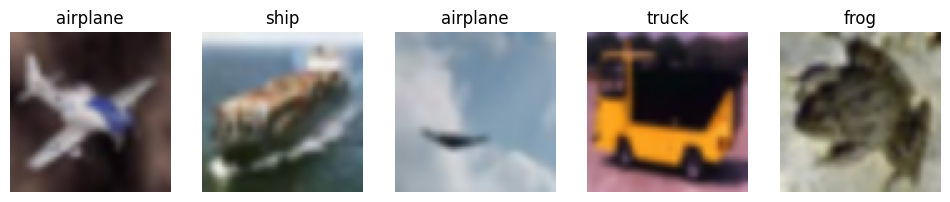

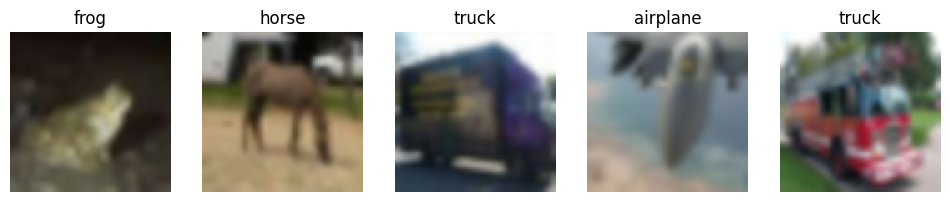

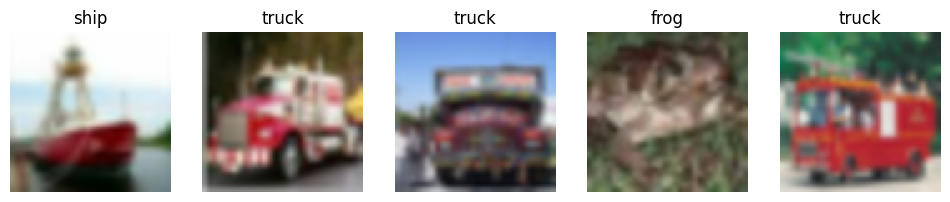

In [ ]:
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(x_train[s].reshape(32,32,3), (32*k, 32*k)))
    ax[i].set_title(label[np.argmax(y_train[s])])
    ax[i].set_axis_off()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 500)                 │       1,536,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 500)                 │         250,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           5,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,792,010 (6.84 MB)

 Trainable params: 1,792,010 (6.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 - 11s - 114ms/step - accuracy: 0.2758 - loss: 2.0555 - val_accuracy: 0.3408 - val_loss: 1.8421
Epoch 2/40
100/100 - 0s - 5ms/step - accuracy: 0.3789 - loss: 1.7519 - val_accuracy: 0.4111 - val_loss: 1.6779
Epoch 3/40
100/100 - 0s - 5ms/step - accuracy: 0.4070 - loss: 1.6634 - val_accuracy: 0.4261 - val_loss: 1.6199
Epoch 4/40
100/100 - 0s - 5ms/step - accuracy: 0.4357 - loss: 1.5825 - val_accuracy: 0.4513 - val_loss: 1.5539
Epoch 5/40
100/100 - 0s - 5ms/step - accuracy: 0.4527 - loss: 1.5353 - val_accuracy: 0.4654 - val_loss: 1.5123
Epoch 6/40
100/100 - 0s - 5ms/step - accuracy: 0.4669 - loss: 1.4941 - val_accuracy: 0.4773 - val_loss: 1.4813
Epoch 7/40
100/100 - 0s - 5ms/step - accuracy: 0.4819 - loss: 1.4572 - val_accuracy: 0.4727 - val_loss: 1.4698
Epoch 8/40
100/100 - 0s - 5ms/step - accuracy: 0.4952 - loss: 1.4237 - val_accuracy: 0.4872 - val_loss: 1.4403
Epoch 9/40
100/100 - 1s - 5ms/step - accuracy: 0.5011 - loss: 1.4054 - val_accuracy: 0.4730 - val_loss: 1.487

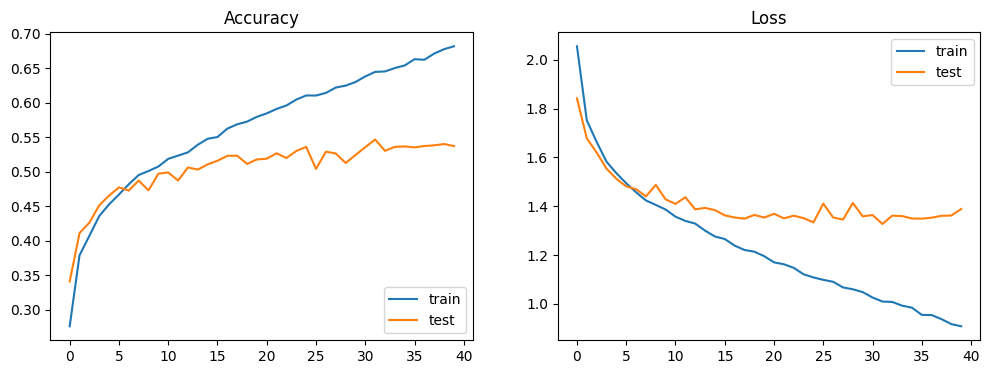

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
Elapsed time training= 31.7368 secs
Mean squared error = 0.061
Accuracy = 0.5371
The highest training accuracy was 0.6820 obtained in epoch 40
The final training accuracy was 0.6820
The highest validation accuracy was 0.5467 obtained in epoch 32
The final validation accuracy was 0.5372
The lowest training loss was 0.9080 obtained in epoch 40
The final training loss was 0.9080
The lowest validation loss was 1.3273 obtained in epoch 32
The final validation loss was 1.3886


In [ ]:
def ffnn(n_inputs,hidden_layers):
  model = tf.keras.Sequential()
  model.add(Input(shape=(n_inputs,)))
  for units in hidden_layers:
    model.add(Dense(units,  activation='relu'))
  model.add(Dense(10,  activation='softmax'))
  return model

model = ffnn(x_train.shape[1],[500,500])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 500,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

We obtain an accuracy of around 54%. We can see that the network starts overfitting, as the validation loss starts increasing around epoch 20 to 25.

## Randomly Shuffling the Columns of the Train and Test Arrays

Since the network treats each of the 3072 attributes independently, if we shuffle the columns in the training data, we expect to see the same performance. Let's see if this is the case.

In [ ]:
ind = np.random.permutation(x_train.shape[1])
x_train = x_train[:,ind]
x_test = x_test[:,ind]

Now let's see the resulting images.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 500)                 │       1,536,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 500)                 │         250,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           5,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,792,010 (6.84 MB)

 Trainable params: 1,792,010 (6.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 - 4s - 45ms/step - accuracy: 0.2603 - loss: 2.1169 - val_accuracy: 0.3399 - val_loss: 1.8471
Epoch 2/40
100/100 - 0s - 5ms/step - accuracy: 0.3717 - loss: 1.7629 - val_accuracy: 0.3931 - val_loss: 1.7102
Epoch 3/40
100/100 - 1s - 5ms/step - accuracy: 0.4031 - loss: 1.6724 - val_accuracy: 0.4209 - val_loss: 1.6261
Epoch 4/40
100/100 - 1s - 5ms/step - accuracy: 0.4290 - loss: 1.6105 - val_accuracy: 0.4381 - val_loss: 1.5803
Epoch 5/40
100/100 - 0s - 5ms/step - accuracy: 0.4504 - loss: 1.5526 - val_accuracy: 0.4359 - val_loss: 1.5921
Epoch 6/40
100/100 - 0s - 5ms/step - accuracy: 0.4611 - loss: 1.5264 - val_accuracy: 0.4588 - val_loss: 1.5297
Epoch 7/40
100/100 - 1s - 5ms/step - accuracy: 0.4736 - loss: 1.4885 - val_accuracy: 0.4656 - val_loss: 1.5038
Epoch 8/40
100/100 - 0s - 5ms/step - accuracy: 0.4858 - loss: 1.4505 - val_accuracy: 0.4812 - val_loss: 1.4636
Epoch 9/40
100/100 - 0s - 5ms/step - accuracy: 0.4974 - loss: 1.4195 - val_accuracy: 0.4892 - val_loss: 1.4373


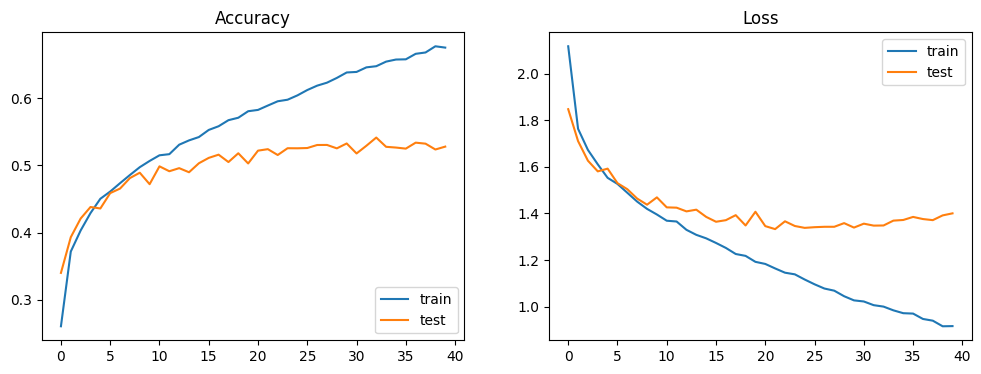

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Elapsed time training= 24.5128 secs
Mean squared error = 0.062
Accuracy = 0.5281
The highest training accuracy was 0.6776 obtained in epoch 39
The final training accuracy was 0.6757
The highest validation accuracy was 0.5416 obtained in epoch 33
The final validation accuracy was 0.5281
The lowest training loss was 0.9158 obtained in epoch 39
The final training loss was 0.9166
The lowest validation loss was 1.3326 obtained in epoch 22
The final validation loss was 1.4003


In [ ]:
def ffnn(n_inputs,hidden_layers):
  model = tf.keras.Sequential()
  model.add(Input(shape=(n_inputs,)))
  for units in hidden_layers:
    model.add(Dense(units,  activation='relu'))
  model.add(Dense(10,  activation='softmax'))
  return model

model = ffnn(x_train.shape[1],[500,500])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 500,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

As expected, performance is nearly identical, even though the problem appears much more difficult. The reason for this is that the network fails to exploit features in the dataset that are unique to images, such as the fact that pixels are related to other neighboring pixels and form patterns.

Later we will experiment with convolutional neural networks, which exploit this type of relations.